In [ ]:
import numpy as np
import pandas as pd
import re
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences


In [ ]:
df = pd.read_csv("train.csv",nrows=10000)
df['Review'] = df['Review'].astype(str)
df['Polarity'] = df['Polarity']-1
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    return text

df['cleaned'] = df['Review'].apply(clean_text)


vocab_size = 10000
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(df['cleaned'])
sequences = tokenizer.texts_to_sequences(df['cleaned'])

max_length = 100
X = pad_sequences(sequences, maxlen=max_length, padding='post', truncating='post')
y = df['Polarity'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

embedding_index = {}
with open("glove.6B.100d.txt", encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word, vector = values[0], np.asarray(values[1:], dtype='float32')
        embedding_index[word] = vector

embedding_dim = 100
word_index = tokenizer.word_index
embedding_matrix = np.zeros((vocab_size, embedding_dim))
for word, i in word_index.items():
    if i < vocab_size:
        embedding_vector = embedding_index.get(word)
        if embedding_vector is not None:
            embedding_matrix[i] = embedding_vector

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Embedding(input_dim=vocab_size,
                              output_dim=embedding_dim,
                              weights=[embedding_matrix],
                              input_length=max_length,
                              trainable=False),
    tf.keras.layers.Bidirectional(tf.keras.layers.GRU(128, dropout=0.2, recurrent_dropout=0.2)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

2025-06-10 19:19:19.745723: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3 Pro
2025-06-10 19:19:19.745742: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 18.00 GB
2025-06-10 19:19:19.745746: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 6.00 GB
2025-06-10 19:19:19.745801: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:303] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-06-10 19:19:19.745999: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:269] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [ ]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 100, 100)          1000000   
                                                                 
 bidirectional (Bidirection  (None, 256)               176640    
 al)                                                             
                                                                 
 dense (Dense)               (None, 64)                16448     
                                                                 
 dropout (Dropout)           (None, 64)                0         
                                                                 
 dense_1 (Dense)             (None, 1)                 65        
                                                                 
Total params: 1193153 (4.55 MB)
Trainable params: 193153 (754.50 KB)
Non-trainable params: 1000000 (3.81 MB)
_____________

In [8]:
from keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', mode='min', patience=0, restore_best_weights=True)

history = model.fit(X_train, y_train, validation_split=0.2, epochs=10,batch_size=512, callbacks=[early_stop])

Epoch 1/10
15/15 [==============================] - 312s 21s/step - loss: 0.6094 - accuracy: 0.6953 - val_loss: 0.5227 - val_accuracy: 0.7417
Epoch 2/10
15/15 [==============================] - 314s 21s/step - loss: 0.5692 - accuracy: 0.7143 - val_loss: 0.4992 - val_accuracy: 0.7583
Epoch 3/10
15/15 [==============================] - 309s 21s/step - loss: 0.5430 - accuracy: 0.7403 - val_loss: 0.4804 - val_accuracy: 0.7689
Epoch 4/10
15/15 [==============================] - 309s 21s/step - loss: 0.5321 - accuracy: 0.7399 - val_loss: 0.4811 - val_accuracy: 0.7678


In [9]:
predictions = (model.predict(X_test) > 0.5).astype(int).flatten()
print("\nClassification Report:\n", classification_report(y_test, predictions))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, predictions))

32/32 [==============================] - 20s 638ms/step

Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.86      0.79       504
           1       0.82      0.68      0.75       496

    accuracy                           0.77      1000
   macro avg       0.78      0.77      0.77      1000
weighted avg       0.78      0.77      0.77      1000


Confusion Matrix:
 [[432  72]
 [158 338]]


In [7]:
# Find me the sentences where there is the mismatch of predictions
mismatched_indices = np.where(predictions != y_test)[0]
mismatched_sentences = df.iloc[mismatched_indices]['Review'].values
print("\nMismatched Sentences:")
for sentence in mismatched_sentences:
    print(sentence)
# Save this to a csv file , with the columns 'Review', 'Predicted', 'Actual' and clip the review to 100 characters
mismatched_sentences = [sentence[:100] for sentence in mismatched_sentences]
mismatched_df = pd.DataFrame({
    'Review': mismatched_sentences,
    'Predicted': predictions[mismatched_indices],
    'Actual': y_test[mismatched_indices]
})
mismatched_df.to_csv("mismatched_predictions.csv", index=False)


Mismatched Sentences:
I'm reading a lot of reviews saying that this is the best 'game soundtrack' and I figured that I'd write a review to disagree a bit. This in my opinino is Yasunori Mitsuda's ultimate masterpiece. The music is timeless and I'm been listening to it for years now and its beauty simply refuses to fade.The price tag on this is pretty staggering I must say, but if you are going to buy any cd for this much money, this is the only one that I feel would be worth every penny.
This soundtrack is my favorite music of all time, hands down. The intense sadness of "Prisoners of Fate" (which means all the more if you've played the game) and the hope in "A Distant Promise" and "Girl who Stole the Star" have been an important inspiration to me personally throughout my teen years. The higher energy tracks like "Chrono Cross ~ Time's Scar~", "Time of the Dreamwatch", and "Chronomantique" (indefinably remeniscent of Chrono Trigger) are all absolutely superb as well.This soundtrack is

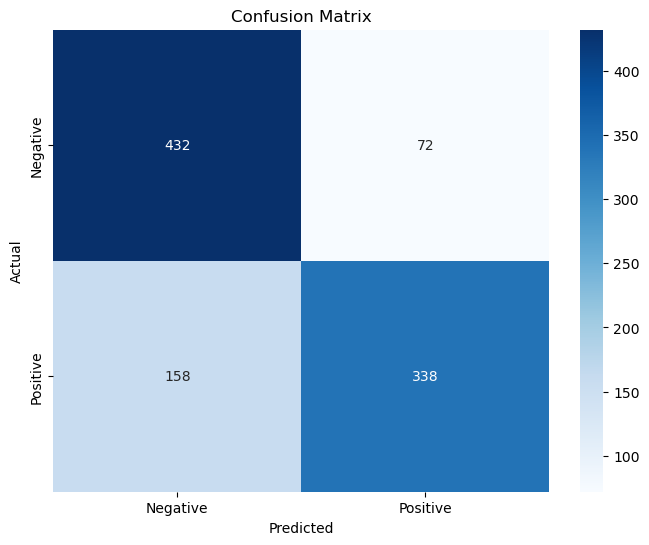

In [10]:
# making the confusion matrix plot
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.savefig("confusion_matrix.png")
plt.show()

